[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skarma91/logicmojo-ai-july-2026/blob/main/modules/module-2-ml-dl-essentials/04-pytorch-fundamentals/code/pytorch_fundamentals.ipynb)

# Class 2.4: PyTorch fundamentals

The slides carry the ideas. Here you meet tensors and autograd, then code the training loop from class 2.2 (How models learn) for real and train a classifier on the digits dataset.

What we will cover:
- tensors and autograd (gradients computed for you)
- losses and optimizers, and why logits go to CrossEntropyLoss
- an nn.Module and the five-line training loop on real data
- the zero_grad trap


## Setup

You need PyTorch for this notebook; the CPU build is fine. scikit-learn (from class 2.1, What is machine learning) is also used and already installed. To install PyTorch in your virtual environment, run:

```
pip install torch
```


## Tensors

A tensor behaves like a NumPy array (shape, dtype, broadcasting) with two extras: it can run on a GPU and it can track gradients.

In [1]:
import torch

t = torch.tensor([[2., 4., 6.],
                  [1., 3., 5.]])
print("shape:", t.shape, "| dtype:", t.dtype)
print("t + 10:\n", t + 10)
print("row means:", t.mean(dim=1))   # broadcasting and reductions, as in NumPy

shape: torch.Size([2, 3]) | dtype: torch.float32
t + 10:
 tensor([[12., 14., 16.],
        [11., 13., 15.]])
row means: tensor([4., 3.])


## Autograd: gradients for free

Track a tensor with `requires_grad=True`, build a value from it, call `.backward()`, and read the gradient. PyTorch built a graph of the operations and differentiated it for you.

In [2]:
x = torch.tensor([2., 3., 4.], requires_grad=True)
y = (x ** 3).sum()          # y = 8 + 27 + 64 = 99
y.backward()
print("y:", y.item())
print("x.grad:", x.grad)    # d/dx of x^3 is 3*x^2 = [12, 27, 48], computed for us

y: 99.0
x.grad: tensor([12., 27., 48.])


## Losses, and why logits go to CrossEntropyLoss

`CrossEntropyLoss` applies softmax internally, so you pass it raw logits. Softmax them yourself first and you apply softmax twice, which weakens the signal. See the two losses differ.

In [3]:
import torch.nn as nn
import torch.nn.functional as F

logits = torch.tensor([[2.0, 0.5, 0.1]])   # one example, 3 classes
target = torch.tensor([2])                 # true class is 0

ce = nn.CrossEntropyLoss()
correct = ce(logits, target)                       # right: raw logits
probs = F.softmax(logits, dim=1)
double = ce(probs, target)                         # wrong: softmax already applied
print("loss on raw logits (correct):", round(float(correct), 4))
print("loss on softmaxed input (wrong):", round(float(double), 4), " <- weaker signal")

loss on raw logits (correct): 2.2168
loss on softmaxed input (wrong): 1.3643  <- weaker signal


## An nn.Module

`nn.Module` holds the layers and their parameters. `forward` is the class 2.3 (Neural networks) forward pass, returning raw logits.

In [4]:
class Net(nn.Module):
    def __init__(self, in_features, hidden, classes):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden, classes)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)                 # raw logits

model = Net(64, 32, 10)
n_params = sum(p.numel() for p in model.parameters())
print("total parameters:", n_params)      # (64*32+32) + (32*10+10)

total parameters: 2410


## The five-line loop on real data

Load the digits dataset (1797 images, 8x8, ten classes), split it into train and test sets, scale the features, then train a classifier. Before training, we show a few examples so the data feels real and the labels are easy to read.

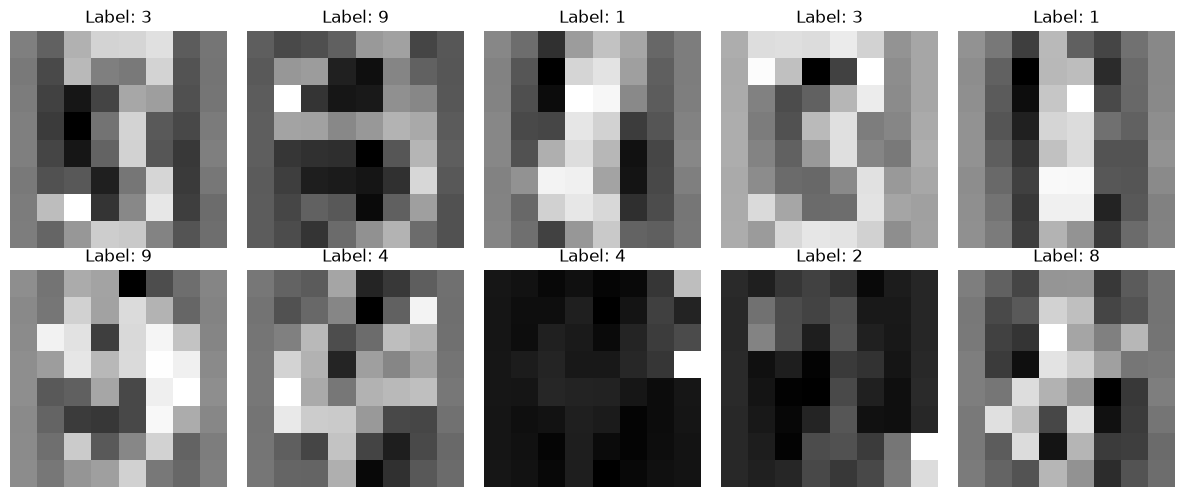

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Load digits data
Xd, yd = load_digits(return_X_y=True)

# Split into train/test
X_tr, X_te, y_tr, y_te = train_test_split(
    Xd, yd, test_size=0.2, random_state=0, stratify=yd
)

# Scale features
scaler = StandardScaler().fit(X_tr)
X_tr = torch.tensor(scaler.transform(X_tr), dtype=torch.float32)
X_te = torch.tensor(scaler.transform(X_te), dtype=torch.float32)
y_tr = torch.tensor(y_tr)
y_te = torch.tensor(y_te)

# Show a few sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, image, label in zip(axes.flat, X_tr[:10], y_tr[:10]):
    ax.imshow(image.view(8, 8), cmap="gray")
    ax.set_title(f"Label: {int(label)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# Model and optimizer
model = Net(64, 32, 10)
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.01)

# Train
model.train()
for step in range(300):
    logits = model(X_tr)              # 1. predict
    loss = loss_fn(logits, y_tr)      # 2. measure
    opt.zero_grad()                   # 3. clear
    loss.backward()                   # 4. differentiate
    opt.step()                        # 5. step -> parameter update

    if step % 20 == 0 or step == 299:
        print(f"step {step:3d}  loss {loss.item():.3f}")

step   0  loss 2.347
step  20  loss 0.208
step  40  loss 0.062
step  60  loss 0.028
step  80  loss 0.015
step 100  loss 0.010
step 120  loss 0.007
step 140  loss 0.005
step 160  loss 0.004
step 180  loss 0.003
step 200  loss 0.003
step 220  loss 0.002
step 240  loss 0.002
step 260  loss 0.002
step 280  loss 0.001
step 299  loss 0.001


In [7]:
# Eval
model.eval()
with torch.no_grad():
    logits = model(X_te)
    preds = logits.argmax(dim=1)
    acc = (preds == y_te).float().mean()

print("test accuracy:", round(float(acc), 3))

test accuracy: 0.964


## The zero_grad trap

Gradients accumulate. Skip `zero_grad()` and each `.backward()` adds to the last one, inflating the step.

In [8]:
w = torch.tensor([1.0], requires_grad=True)
print("without zero_grad (gradient of the same loss keeps growing):")
for step in range(3):
    (w ** 2).sum().backward()          # true gradient is 2*w = 2.0 every time
    print(f"  step {step}: w.grad = {float(w.grad)}")

print("with zero_grad (correct, steady 2.0):")
w = torch.tensor([1.0], requires_grad=True)
for step in range(3):
    if w.grad is not None:
        w.grad.zero_()
    (w ** 2).sum().backward()
    print(f"  step {step}: w.grad = {float(w.grad)}")

without zero_grad (gradient of the same loss keeps growing):
  step 0: w.grad = 2.0
  step 1: w.grad = 4.0
  step 2: w.grad = 6.0
with zero_grad (correct, steady 2.0):
  step 0: w.grad = 2.0
  step 1: w.grad = 2.0
  step 2: w.grad = 2.0


## Your turn

**Micro-assignment.** Six problems in PyTorch; see `../micro-assignment/README.md`.

**Next, class 2.5 (Training in practice):** batches and epochs, learning curves, overfitting control, reproducibility, and saving the model.